In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

In [10]:
df = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", skiprows=1, delimiter=';', decimal=',')
df.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
print(len(df))
df.dropna(inplace=True)
df["Tidspunkt"] = pd.to_datetime(df["Tidspunkt"])
df = df.set_index("Tidspunkt").resample("D").max().reset_index()

peaks = find_peaks(df["Vannføring (m³/s)"].values, height=250, distance=30)
exceedances = df["Vannføring (m³/s)"][peaks[0]]
print(f"number of peaks: {len(peaks[0])}")

209860
number of peaks: 22


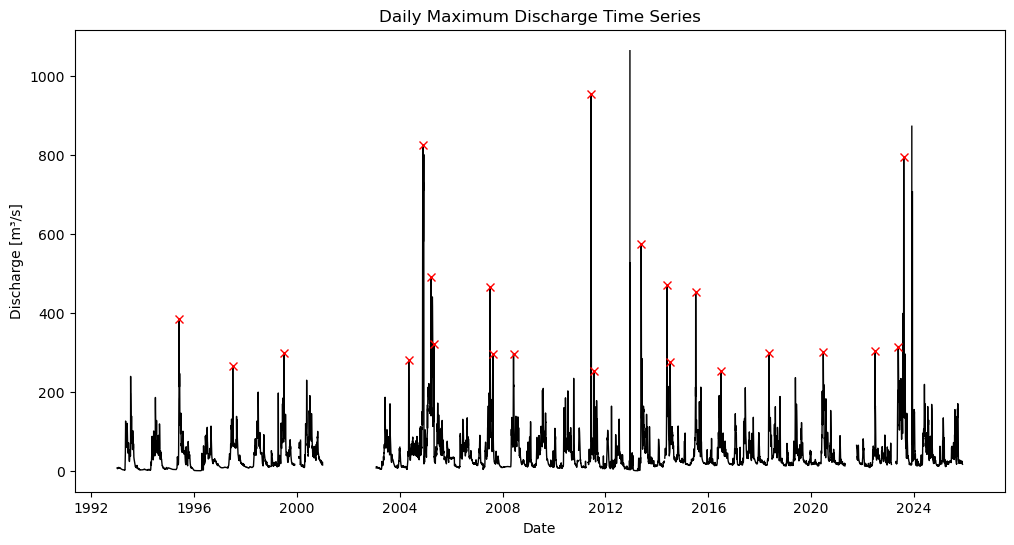

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Tidspunkt"], df["Vannføring (m³/s)"], label="Discharge", color='black', lw=1)
ax.plot(df["Tidspunkt"].iloc[peaks[0]], exceedances, "x", label="Peaks", color='red')
ax.set_title("Daily Maximum Discharge Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge [m³/s]")

plt.savefig("..\\Figures\\Discharge_analysis_timeseries.png", dpi=300)

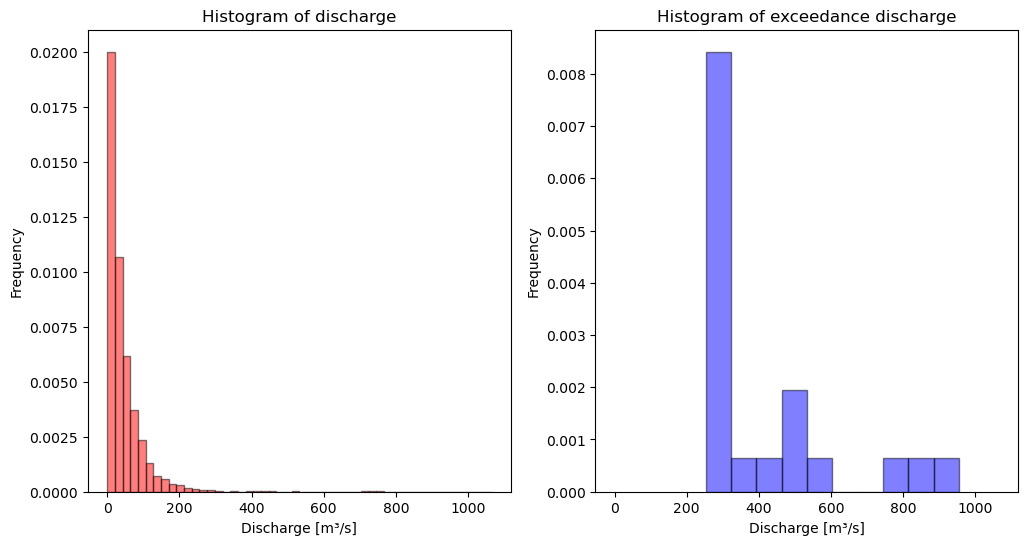

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

axes[0].hist(df["Vannføring (m³/s)"], bins=50, color='red', edgecolor='black', alpha = 0.5, density=True)
axes[0].set_title("Histogram of discharge")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Discharge [m³/s]")

axes[1].hist(exceedances, bins=10, color='blue', edgecolor='black', alpha = 0.5, density=True)
axes[1].set_title("Histogram of exceedance discharge")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Discharge [m³/s]")

plt.savefig("..\\Figures\\Discharge_analysis_hist.png", dpi=300)